In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
import seaborn as sns

In [2]:
# Настройка стиля для лучшей визуализации
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def plot_levels(func, xrange=None, yrange=None, levels=None, ax=None, 
                cmap='viridis', alpha=0.6, linewidth=2.0, 
                fill_contours=True, n_points=200):
    """
    Plotting the contour lines of the function with enhanced visualization.

    Parameters:
    -----------
    func : callable
        Function to plot contours for
    xrange : list, optional
        X-axis range [xmin, xmax]
    yrange : list, optional  
        Y-axis range [ymin, ymax]
    levels : list, optional
        Contour levels to plot
    ax : matplotlib axis, optional
        Axis to plot on
    cmap : str, optional
        Colormap for filled contours
    alpha : float, optional
        Transparency level
    linewidth : float, optional
        Contour line width
    fill_contours : bool, optional
        Whether to fill contours with color
    n_points : int, optional
        Number of points in each dimension for grid

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> plot_levels(oracle.func)
    """
    if xrange is None:
        xrange = [-6, 6]
    if yrange is None:
        yrange = [-5, 5]
    if levels is None:
        levels = [0, 0.25, 1, 4, 9, 16, 25]
        
    # Create grid
    x = np.linspace(xrange[0], xrange[1], n_points)
    y = np.linspace(yrange[0], yrange[1], n_points)
    X, Y = np.meshgrid(x, y)
    
    # Compute function values
    Z = np.zeros(X.shape)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            try:
                Z[i, j] = func(np.array([X[i, j], Y[i, j]]))
            except:
                Z[i, j] = np.nan
    
    # Create axis if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot filled contours
    if fill_contours:
        contourf = ax.contourf(X, Y, Z, levels=50, cmap=cmap, alpha=alpha*0.5)
        # Add colorbar
        plt.colorbar(contourf, ax=ax, label='Function Value')
    
    # Plot contour lines
    CS = ax.contour(X, Y, Z, levels=levels, colors='k', 
                   linewidths=linewidth, alpha=0.8)
    ax.clabel(CS, inline=1, fontsize=9, fmt='%.1f')
    
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title('Function Contour Plot', fontsize=14)
    
    return ax

In [3]:
def plot_trajectory(func, history, fit_axis=False, label=None, ax=None,
                   color='red', marker='o', markersize=6, linewidth=2.5,
                   alpha=1.0, annotate_points=False, show_start_end=True):
    """
    Plotting the trajectory of a method with enhanced features.
    Use after plot_levels(...).

    Parameters:
    -----------
    func : callable
        Objective function
    history : list of arrays
        Optimization trajectory
    fit_axis : bool, optional
        Whether to adjust axis limits to fit trajectory
    label : str, optional  
        Label for legend
    ax : matplotlib axis, optional
        Axis to plot on
    color : str, optional
        Trajectory color
    marker : str, optional
        Point marker style
    markersize : int, optional
        Size of markers
    linewidth : float, optional
        Trajectory line width
    alpha : float, optional
        Transparency
    annotate_points : bool, optional
        Whether to annotate iteration numbers
    show_start_end : bool, optional
        Whether to mark start and end points specially

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> [x_star, msg, history] = optimization.gradient_descent(oracle, np.array([3.0, 1.5], trace=True)
    >> plot_levels(oracle.func)
    >> plot_trajectory(oracle.func, history['x'])
    """
    if ax is None:
        ax = plt.gca()
    
    # Extract trajectory points
    if isinstance(history, dict) and 'x' in history:
        trajectory = history['x']
    elif isinstance(history, list):
        trajectory = history
    else:
        raise ValueError("History should be a list of points or dict with 'x' key")
    
    x_values, y_values = zip(*trajectory)
    
    # Plot trajectory
    line = ax.plot(x_values, y_values, '-', color=color, linewidth=linewidth, 
                   alpha=alpha, label=label)[0]
    
    # Plot points
    points = ax.plot(x_values, y_values, marker, color=color, ms=markersize, 
                    alpha=alpha)[0]
    
    # Mark start and end points
    if show_start_end and len(trajectory) > 1:
        # Start point
        ax.plot(x_values[0], y_values[0], 's', color='green', 
               markersize=markersize+2, label='Start', alpha=0.9)
        # End point  
        ax.plot(x_values[-1], y_values[-1], 'D', color='blue',
               markersize=markersize+2, label='End', alpha=0.9)
    
    # Annotate points with iteration numbers
    if annotate_points and len(trajectory) <= 20:  # Only if not too many points
        for i, (x, y) in enumerate(zip(x_values, y_values)):
            ax.annotate(str(i), (x, y), xytext=(5, 5), 
                       textcoords='offset points', fontsize=8, alpha=0.7)
    
    # Adjust axis limits if requested
    if fit_axis:
        x_margin = (max(x_values) - min(x_values)) * 0.2
        y_margin = (max(y_values) - min(y_values)) * 0.2
        ax.set_xlim(min(x_values) - x_margin, max(x_values) + x_margin)
        ax.set_ylim(min(y_values) - y_margin, max(y_values) + y_margin)
    
    return ax

In [4]:
def plot_optimization_comparison(oracle, histories, labels, xrange=None, yrange=None,
                                figsize=(15, 5), show_contours=True):
    """
    НАША МОДИФИКАЦИЯ: Compare multiple optimization methods on one plot.
    
    Parameters:
    -----------
    oracle : oracle object
        Objective function oracle
    histories : list of history dicts
        Optimization histories for different methods
    labels : list of str
        Method labels
    xrange : list, optional
        X-axis range
    yrange : list, optional
        Y-axis range
    figsize : tuple, optional
        Figure size
    show_contours : bool, optional
        Whether to show contour lines
    """
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    markers = ['o', 's', '^', 'D', 'v', '<']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Trajectories on contour plot
    if show_contours:
        plot_levels(oracle.func, xrange, yrange, ax=ax1)
    
    for i, (history, label) in enumerate(zip(histories, labels)):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        
        plot_trajectory(oracle.func, history, ax=ax1, 
                       color=color, marker=marker, label=label,
                       show_start_end=(i == 0))  # Only show start/end for first method
    
    ax1.legend()
    ax1.set_title('Optimization Trajectories Comparison')
    
    # Plot 2: Function value convergence
    for i, (history, label) in enumerate(zip(histories, labels)):
        color = colors[i % len(colors)]
        
        if isinstance(history, dict) and 'func' in history:
            func_values = history['func']
            iterations = range(len(func_values))
            ax2.semilogy(iterations, func_values, color=color, 
                        linewidth=2, label=label, marker='o', markersize=4)
    
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Function Value (log scale)')
    ax2.set_title('Convergence Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


In [5]:
def plot_gradient_norms(histories, labels, figsize=(10, 6)):
    """
    НАША МОДИФИКАЦИЯ: Plot gradient norms for multiple methods.
    
    Parameters:
    -----------
    histories : list of history dicts
        Optimization histories
    labels : list of str
        Method labels
    figsize : tuple, optional
        Figure size
    """
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    
    plt.figure(figsize=figsize)
    
    for i, (history, label) in enumerate(zip(histories, labels)):
        color = colors[i % len(colors)]
        
        if isinstance(history, dict) and 'grad_norm' in history:
            grad_norms = history['grad_norm']
            iterations = range(len(grad_norms))
            plt.semilogy(iterations, grad_norms, color=color, 
                        linewidth=2, label=label, marker='s', markersize=4)
    
    plt.xlabel('Iteration')
    plt.ylabel('Gradient Norm (log scale)')
    plt.title('Gradient Norm Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

In [6]:
def plot_step_sizes(histories, labels, figsize=(10, 6)):
    """
    НАША МОДИФИКАЦИЯ: Plot step sizes for multiple methods.
    
    Parameters:
    -----------
    histories : list of history dicts
        Optimization histories
    labels : list of str
        Method labels
    figsize : tuple, optional
        Figure size
    """
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    
    plt.figure(figsize=figsize)
    
    for i, (history, label) in enumerate(zip(histories, labels)):
        color = colors[i % len(colors)]
        
        if isinstance(history, dict) and 'alphas' in history:
            alphas = history['alphas']
            iterations = range(len(alphas))
            plt.plot(iterations, alphas, color=color, 
                    linewidth=2, label=label, marker='^', markersize=4)
    
    plt.xlabel('Iteration')
    plt.ylabel('Step Size')
    plt.title('Step Size Evolution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()

In [7]:
def create_optimization_animation(oracle, history, xrange=None, yrange=None,
                                 filename='optimization_animation.gif', 
                                 interval=200, n_frames=50):
    """
    НАША МОДИФИКАЦИЯ: Create animation of optimization process.
    Requires: pip install matplotlib pillow
    
    Parameters:
    -----------
    oracle : oracle object
        Objective function
    history : dict
        Optimization history
    xrange : list, optional
        X-axis range
    yrange : list, optional
        Y-axis range  
    filename : str, optional
        Output filename
    interval : int, optional
        Frame interval in ms
    n_frames : int, optional
        Number of frames to render
    """
    try:
        from matplotlib.animation import FuncAnimation
        import matplotlib.pyplot as plt
    except ImportError:
        print("Animation requires matplotlib")
        return
    
    if 'x' not in history:
        print("History must contain 'x' for animation")
        return
    
    trajectory = history['x']
    if len(trajectory) > n_frames:
        # Subsample trajectory
        indices = np.linspace(0, len(trajectory)-1, n_frames, dtype=int)
        trajectory = [trajectory[i] for i in indices]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_levels(oracle.func, xrange, yrange, ax=ax)
    
    line, = ax.plot([], [], 'ro-', linewidth=2, markersize=6)
    point, = ax.plot([], [], 'go', markersize=10)
    text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12,
                  bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))
    
    def init():
        line.set_data([], [])
        point.set_data([], [])
        text.set_text('')
        return line, point, text
    
    def update(frame):
        x_vals = [p[0] for p in trajectory[:frame+1]]
        y_vals = [p[1] for p in trajectory[:frame+1]]
        
        line.set_data(x_vals, y_vals)
        point.set_data([x_vals[-1]], [y_vals[-1]])
        text.set_text(f'Iteration: {frame}\nPosition: ({x_vals[-1]:.3f}, {y_vals[-1]:.3f})')
        
        return line, point, text
    
    anim = FuncAnimation(fig, update, frames=len(trajectory),
                        init_func=init, blit=True, interval=interval)
    
    # Save animation
    try:
        anim.save(filename, writer='pillow', fps=1000//interval)
        print(f"Animation saved as {filename}")
    except Exception as e:
        print(f"Could not save animation: {e}")
    
    plt.close(fig)
    return anim

In [8]:
# Пример использования новых функций
def demo_enhanced_plots():
    """
    Демонстрация улучшенных функций визуализации
    """
    # Создаем тестовый оракул
    A = np.array([[3.0, 1.0], [1.0, 2.0]])
    b = np.array([1.0, 2.0])
    
    class TestOracle:
        def func(self, x):
            return 0.5 * np.dot(A.dot(x), x) - b.dot(x)
    
    oracle = TestOracle()
    
    # Создаем тестовые траектории
    np.random.seed(42)
    n_points = 20
    
    # Траектория 1: плавное движение к минимуму
    trajectory1 = []
    x0 = np.array([4.0, 4.0])
    for i in range(n_points):
        t = i / (n_points - 1)
        point = x0 * (1 - t) + np.array([0.5, 1.0]) * t + np.random.normal(0, 0.1, 2)
        trajectory1.append(point)
    
    # Траектория 2: осцилляции
    trajectory2 = []
    for i in range(n_points):
        t = i / (n_points - 1)
        point = x0 * (1 - t) + np.array([0.5, 1.0]) * t
        # Добавляем осцилляции
        oscillation = 0.5 * np.sin(i * 0.5) * np.array([1, -1])
        trajectory2.append(point + oscillation)
    
    histories = [{'x': trajectory1}, {'x': trajectory2}]
    labels = ['Gradient Descent', 'Momentum']
    
    # Демонстрация сравнения методов
    plot_optimization_comparison(oracle, histories, labels)
    plt.show()
    
    # Демонстрация отдельных траекторий
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plot_levels(oracle.func, [-2, 5], [-2, 5])
    plot_trajectory(oracle.func, trajectory1, color='red', 
                   label='Method 1', annotate_points=True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plot_levels(oracle.func, [-2, 5], [-2, 5])
    plot_trajectory(oracle.func, trajectory2, color='blue',
                   label='Method 2', annotate_points=True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

C:\Users\MelnikovNM\AppData\Local\Temp\ipykernel_23124\3799636627.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


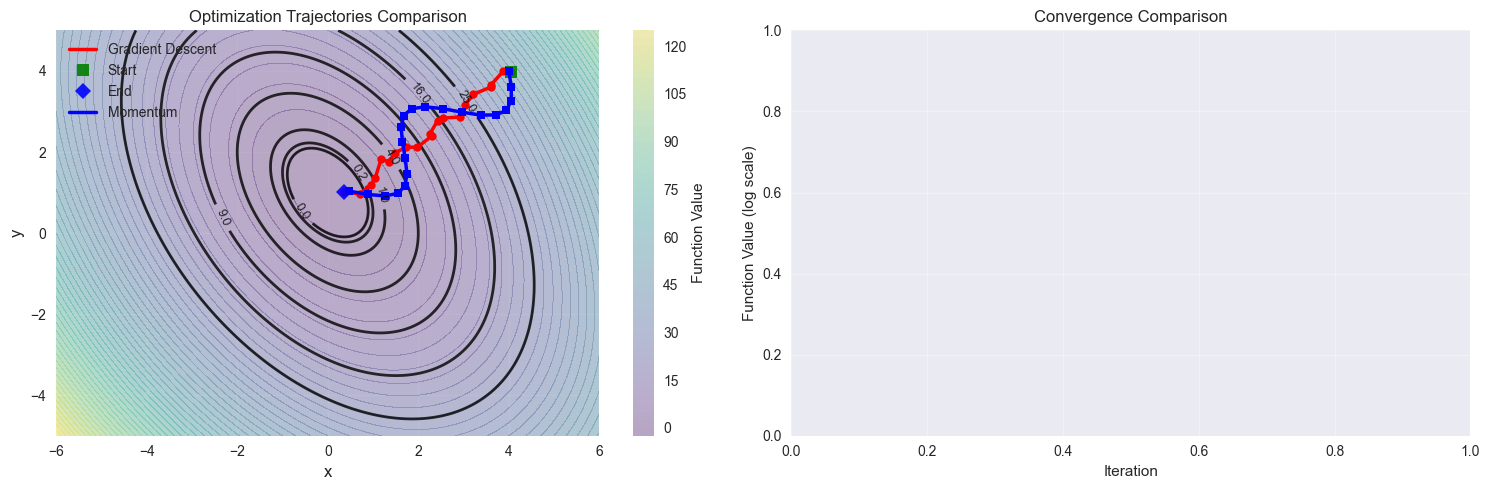

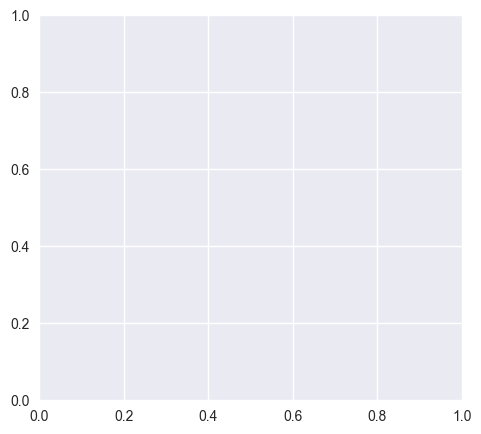

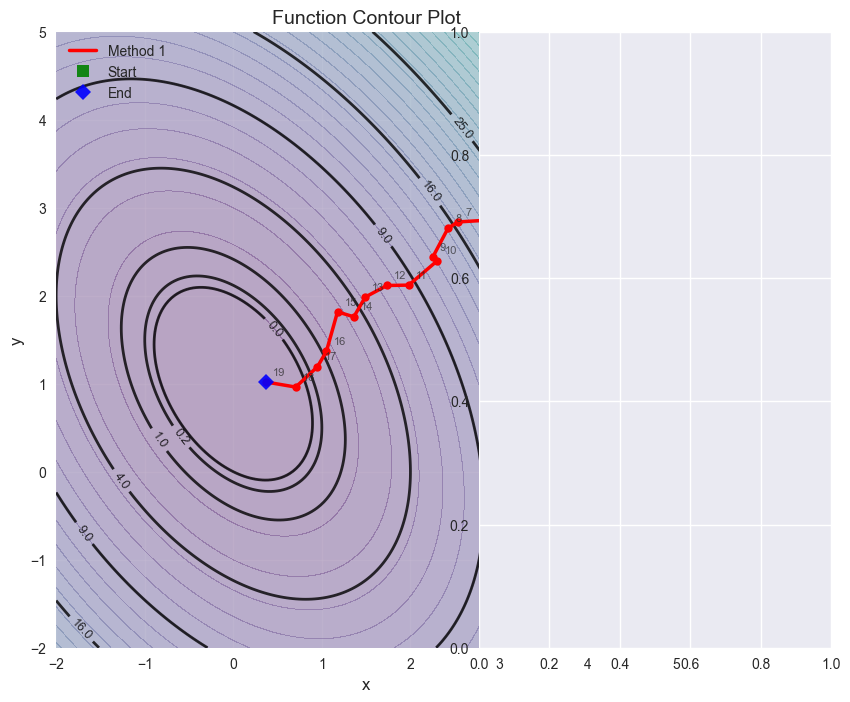

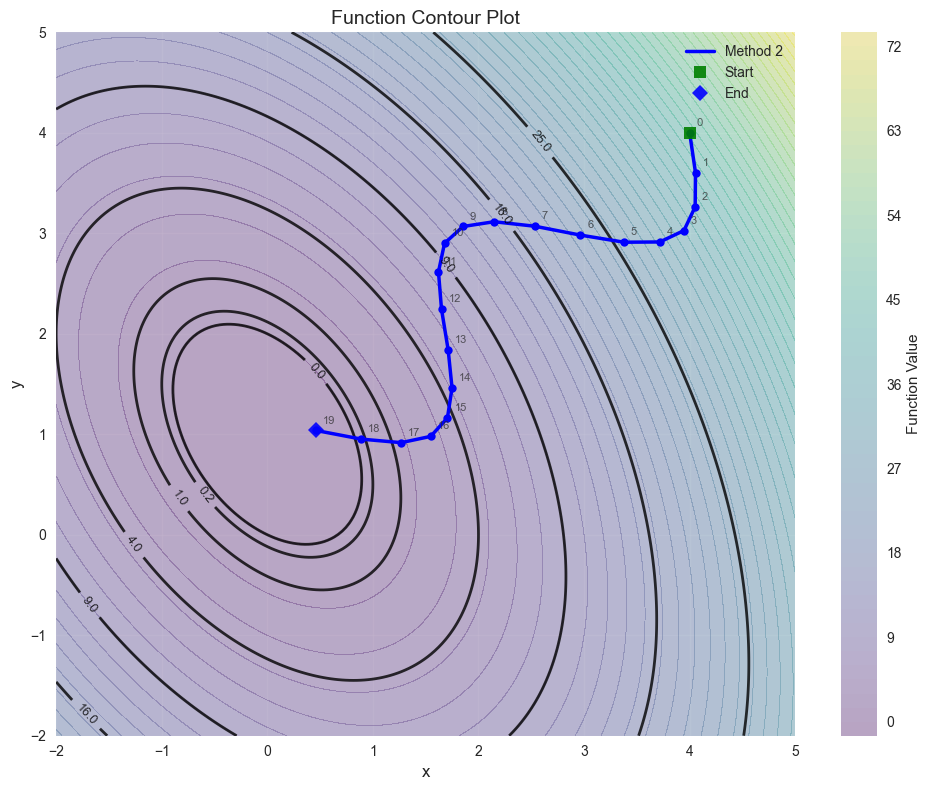

In [9]:
if __name__ == "__main__":
    demo_enhanced_plots()